## Heart Disease Prediction Analysis

In [1]:
########################
### Import libraries ###
########################

import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import pandas as pd
import numpy as np

#### Data parsing, cleaning, and EDA

In [2]:
####################
### Read dataset ###
####################

file_path = 'data/heart_2020_cleaned.csv'
df = pd.read_csv(file_path)
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [3]:
################################
### Check for missing values ###
################################

df.isna().sum()

HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64

In [4]:
###############################
### Parse and clean dataset ###
###############################

# Replace '80 or older' with '80+' for better readability
df['AgeCategory'] = df['AgeCategory'].replace('80 or older', '80+')
# Convert binary string columns to numeric (1 for 'Yes', 0 for 'No')
binary_str_cols = ['HeartDisease', 'Smoking', 'AlcoholDrinking', 'Stroke',
               'DiffWalking', 'Diabetic', 'PhysicalActivity', 'Asthma',
               'KidneyDisease', 'SkinCancer']
for col in binary_str_cols:
    df[col] = df[col].map(lambda x: 1 if x == "Yes" else 0)
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,1,0,0,3.0,30.0,0,Female,55-59,White,1,1,Very good,5.0,1,0,1
1,0,20.34,0,0,1,0.0,0.0,0,Female,80+,White,0,1,Very good,7.0,0,0,0
2,0,26.58,1,0,0,20.0,30.0,0,Male,65-69,White,1,1,Fair,8.0,1,0,0
3,0,24.21,0,0,0,0.0,0.0,0,Female,75-79,White,0,0,Good,6.0,0,0,1
4,0,23.71,0,0,0,28.0,0.0,1,Female,40-44,White,0,1,Very good,8.0,0,0,0


In [5]:
##########################
### Summary statistics ###
##########################

df.describe(include='all')

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
count,319795.000000,319795.000000,319795.000000,319795.000000,319795.000000,319795.00000,319795.000000,319795.000000,319795,319795,319795,319795.000000,319795.000000,319795,319795.000000,319795.000000,319795.000000,319795.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,13,6,NaN,NaN,5,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Female,65-69,White,NaN,NaN,Very good,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,167805,34151,245212,NaN,NaN,113858,NaN,NaN,NaN,NaN
mean,0.085595,28.325399,0.412477,0.068097,0.037740,3.37171,3.898366,0.138870,NaN,NaN,NaN,0.127588,0.775362,NaN,7.097075,0.134061,0.036833,0.093244
std,0.279766,6.356100,0.492281,0.251912,0.190567,7.95085,7.955235,0.345812,NaN,NaN,NaN,0.333631,0.417344,NaN,1.436007,0.340718,0.188352,0.290775
min,0.000000,12.020000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,1.000000,0.000000,0.000000,0.000000
25%,0.000000,24.030000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,NaN,NaN,NaN,0.000000,1.000000,NaN,6.000000,0.000000,0.000000,0.000000
50%,0.000000,27.340000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,NaN,NaN,NaN,0.000000,1.000000,NaN,7.000000,0.000000,0.000000,0.000000
75%,0.000000,31.420000,1.000000,0.000000,0.000000,2.00000,3.000000,0.000000,NaN,NaN,NaN,0.000000,1.000000,NaN,8.000000,0.000000,0.000000,0.000000


#### Testing for association between age and heart disease

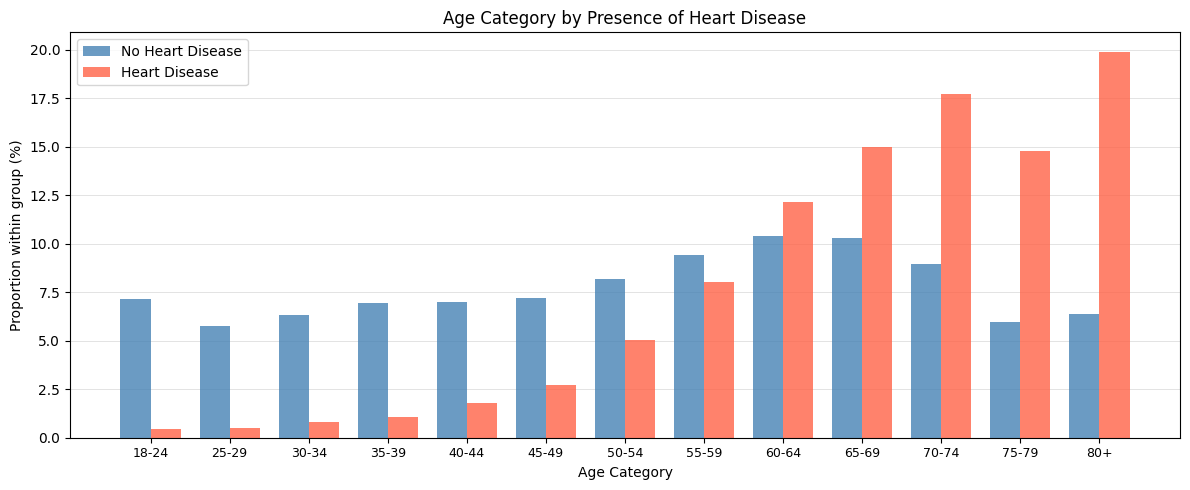

In [6]:
###################################################
### Visualize age distribution of heart disease ###
###################################################

age_order = ['18-24','25-29','30-34','35-39','40-44','45-49',
             '50-54','55-59','60-64','65-69','70-74','75-79','80+']

true_counts  = df[df['HeartDisease'] == 1]['AgeCategory'].value_counts(normalize=True).reindex(age_order) * 100
false_counts  = df[df['HeartDisease'] == 0]['AgeCategory'].value_counts(normalize=True).reindex(age_order) * 100

x = np.arange(len(age_order))
width = 0.38
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, false_counts, width, label='No Heart Disease', color='steelblue', alpha=0.8)
ax.bar(x + width/2, true_counts, width, label='Heart Disease', color='tomato', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(age_order, fontsize=9)
ax.set_xlabel('Age Category')
ax.set_ylabel('Proportion within group (%)')
ax.set_title('Age Category by Presence of Heart Disease')
ax.legend()
ax.grid(axis='y', linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [7]:
# Chi-squared test for association between age category and heart disease
contingency = pd.crosstab(df['HeartDisease'], df['AgeCategory'])
res = stats.chi2_contingency(contingency)
print(f"Test Statistic: {res.statistic}")
print(f"p-value: {res.pvalue}")

Test Statistic: 19299.92039113256
p-value: 0.0


Statistical Test: Chi-squared test

Null Hypothesis (H_0): There is no association between age category and heart disease.

Alternative Hypothesis (H_a): There is an association between age category and heart disease.

Since the p-value of the Chi-squared test is less than 0.05, we reject the null hypothesis and conclude that there is a statistically significant association between age category and heart disease. As seen in the grouped bar chart, the proportion of individuals with heart disease increases with age, suggesting that older age categories (specifically 60 and above) are more likely to have heart disease compared to younger age categories.

#### Investigating if people who smoke and drink have a higher risk of heart disease compared to those that just smoke or drink

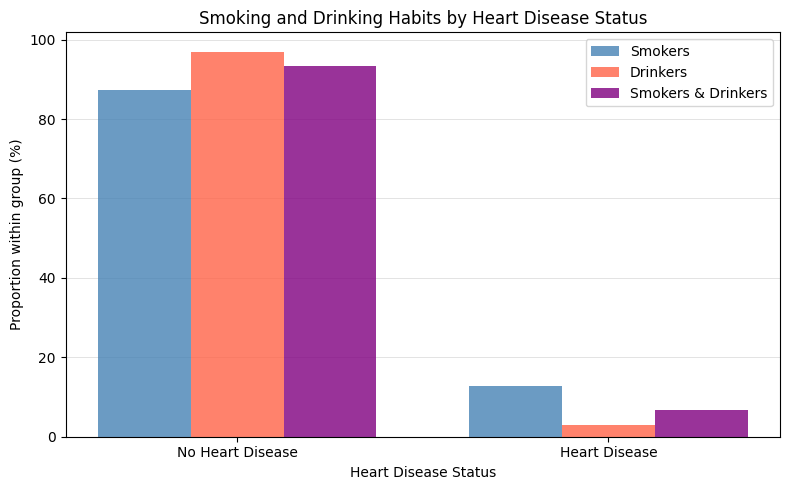

In [8]:
#######################################################################
### Visualize smoking and drinking habits of heart disease patients ###
#######################################################################

smoker_counts  = df[(df['Smoking'] == 1) & (df['AlcoholDrinking'] == 0)]['HeartDisease'].value_counts(normalize=True) * 100
drinker_counts  = df[(df['Smoking'] == 0) & (df['AlcoholDrinking'] == 1)]['HeartDisease'].value_counts(normalize=True) * 100
both_counts  = df[(df['Smoking'] == 1) & (df['AlcoholDrinking'] == 1)]['HeartDisease'].value_counts(normalize=True) * 100

labels = ['No Heart Disease', 'Heart Disease']
x = np.arange(len(labels))
width = 0.25
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width, smoker_counts, width, label='Smokers', color='steelblue', alpha=0.8)
ax.bar(x, drinker_counts, width, label='Drinkers', color='tomato', alpha=0.8)
ax.bar(x + width, both_counts, width, label='Smokers & Drinkers', color='purple', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('Heart Disease Status')
ax.set_ylabel('Proportion within group (%)')
ax.set_title('Smoking and Drinking Habits by Heart Disease Status')
ax.legend()
ax.grid(axis='y', linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [9]:
# ANOVA test for association between smoking/drinking habits and heart disease
smoker_group = df[(df['Smoking'] == 1) & (df['AlcoholDrinking'] == 0)]['HeartDisease']
drinker_group = df[(df['Smoking'] == 0) & (df['AlcoholDrinking'] == 1)]['HeartDisease']
both_group = df[(df['Smoking'] == 1) & (df['AlcoholDrinking'] == 1)]['HeartDisease']
f_stat, p_value = stats.f_oneway(smoker_group, drinker_group, both_group)
print(f"F-statistic: {f_stat}")
print(f"p-value: {p_value}")

# Post Hoc Tukey's HSD test
tukey = stats.tukey_hsd(smoker_group, drinker_group, both_group)
print("\nTukey HSD Post Hoc Test Results:")
print(tukey.pvalue)

F-statistic: 547.3207796073817
p-value: 1.6761217111020712e-237

Tukey HSD Post Hoc Test Results:
[[1.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.00000000e+00 9.99200722e-16]
 [0.00000000e+00 9.99200722e-16 1.00000000e+00]]


Statistical Test: ANOVA test + Tukey HSD Post Hoc Test

Null Hypothesis (H_0): There is no effect of smoking and drinking status on heart disease prevalence.

Alternative Hypothesis (H_a): There is an effect of smoking and drinking status on heart disease prevalence.

Since the p-value of the ANOVA test is well below 0.05, we reject the null hypothesis and conclude that there is a statistically significant difference in heart disease prevalence among individuals who only smoke, only drink, or do both. After running a Tukey HSD Post Hoc Test, we can identify which specific groups differ significantly from each other (all pairwise comparisons are significant). Therefore, each group (smoking, drinking, or both) has a distinct heart disease rate. As seen in the bar chart, those who only smoke have a higher prevalence of heart disease compared to those who only drink. This suggests that smoking may have a stronger association with heart disease than drinking. Since both smoking and alcohol drinking affect heart disease prevalance, it is interesting that the combination of both is not significantly higher than just smoking alone.

### Checking for correlation between features

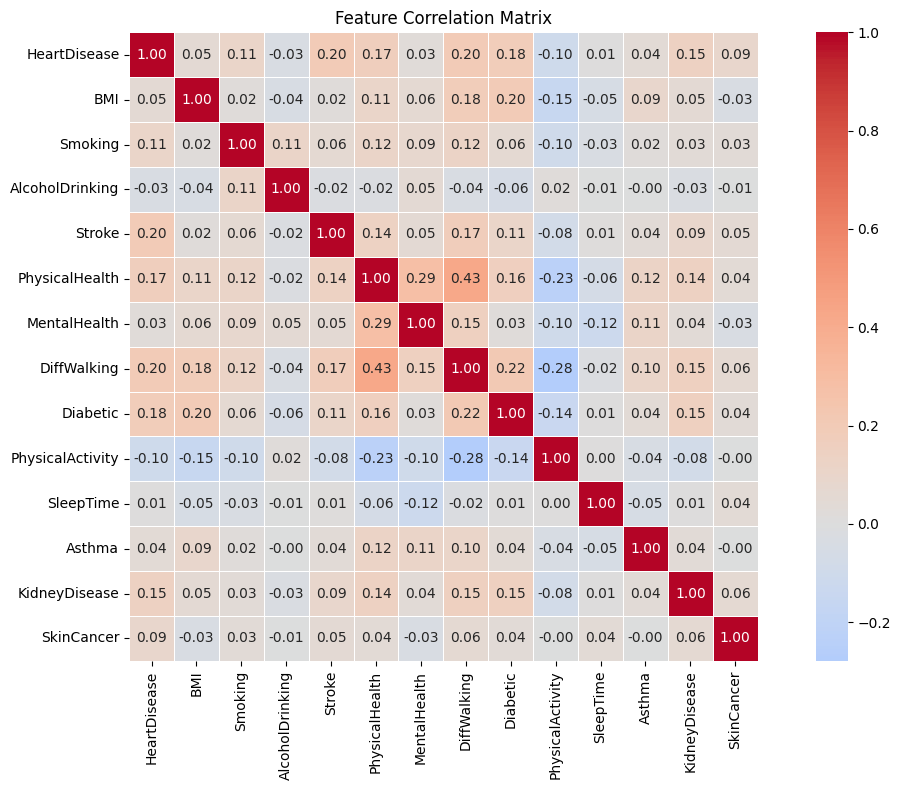

In [10]:
#################################################################################
### Use Pearson correlation for numeric features and visualize with a heatmap ###
#################################################################################

numeric_cols = df.select_dtypes(include='number')
corr = numeric_cols.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

It seems as though there are some slight correlations between features but most are relatively weak showing that most features are independent of one another. The most significant correlation was between PhysicalHealth and DiffWalking with a value of 0.43. This suggests that these features may be somewhat related which makes sense as they both relate to physical well-being. However, there are no extremely high correlations that would indicate any conflicting issues. This suggests that these features provide unique information for predicting heart disease.

#### Testing for association between sex and heart disease

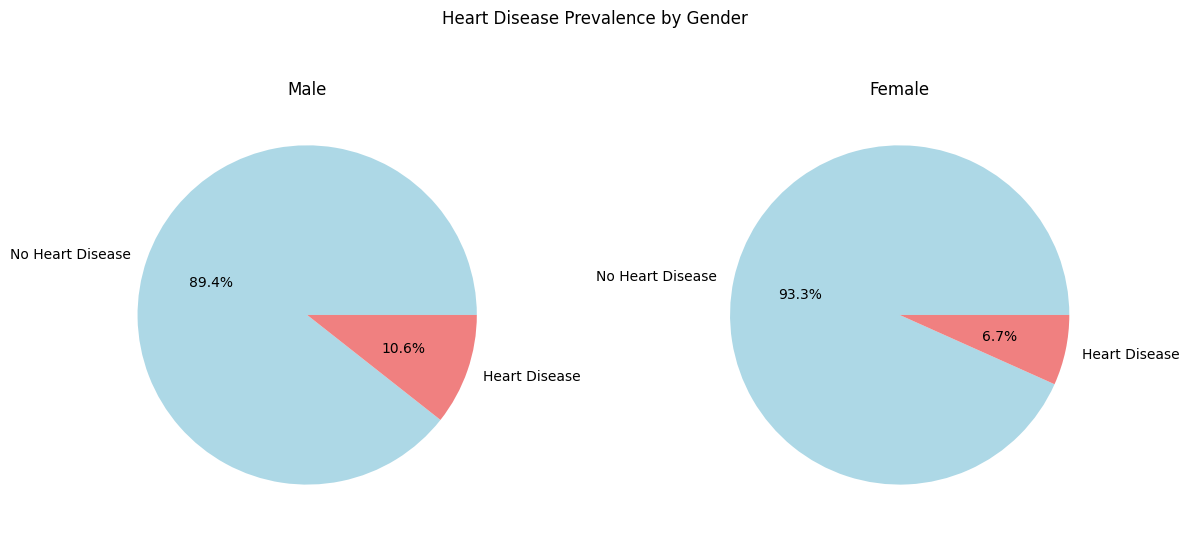

In [11]:
################################################
### Visualize impact of sex on heart disease ###
################################################

male_counts = df[df["Sex"] == "Male"]["HeartDisease"].value_counts(normalize=True) * 100
female_counts = df[df["Sex"] == "Female"]["HeartDisease"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].pie(male_counts, labels=['No Heart Disease', 'Heart Disease'], autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
axes[0].set_title('Male')
axes[1].pie(female_counts, labels=['No Heart Disease', 'Heart Disease'], autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
axes[1].set_title('Female')
plt.suptitle('Heart Disease Prevalence by Gender')
plt.tight_layout()
plt.show()

In [12]:
# Chi square test for association between sex and heart disease
contingency = pd.crosstab(df['HeartDisease'], df['Sex'])
res = stats.chi2_contingency(contingency)
print(f"Test Statistic: {res.statistic}")
print(f"p-value: {res.pvalue}")

Test Statistic: 1568.3069168517372
p-value: 0.0


Statistical Test: Chi-squared test

Null Hypothesis (H_0): There is no association between sex and heart disease.

Alternative Hypothesis (H_a): There is an association between sex and heart disease.

Since the p-value of the Chi-squared test is less than 0.05, we reject the null hypothesis and conclude that there is a statistically significant association between sex and heart disease. As seen in the pie charts, the proportion of individuals with heart disease differs between males and females.